In [ ]:
"""
The goal of this small notebook is to provide a way to vizualise different statistics, 
based on our ground truth. It is not meant to be integrated to the main pipeline, but rather to give us 
external ways to analyse our results.
"""
import cv2
import pandas as pds
import matplotlib.pyplot as plt


In [ ]:

# Note : don't forget to install odfpy : pip install odfpy
df = pds.read_excel('analyse_verite_terrain.ods', sheet_name=None)

In [3]:
left_sheet = df["OEIL GAUCHE"]
right_sheet = df["OEIL DROIT"]

/tmp/ipykernel_16287/3971154448.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_16287/3971154448.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


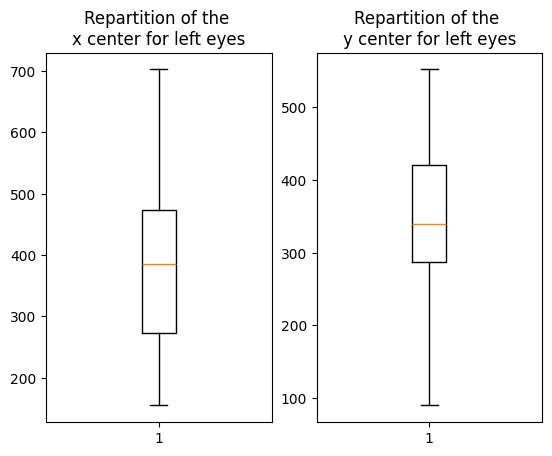

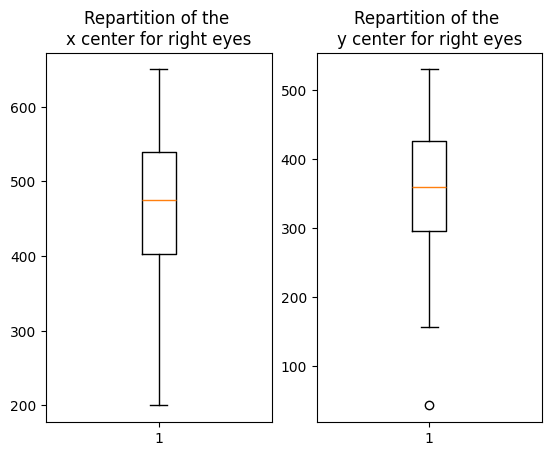

In [5]:
# Different ways to represent stats
fig, axs = plt.subplots(1, 2)

axs[0].boxplot(left_sheet.pos_centre_x)
axs[0].set_title('Repartition of the \nx center for left eyes')
axs[1].boxplot(left_sheet.pos_centre_y)
axs[1].set_title('Repartition of the \ny center for left eyes')
fig.show()

fig, axs = plt.subplots(1, 2)
axs[0].boxplot(right_sheet.pos_centre_x)
axs[0].set_title('Repartition of the \nx center for right eyes')
axs[1].boxplot(right_sheet.pos_centre_y)
axs[1].set_title('Repartition of the \ny center for right eyes')
fig.show()

/tmp/ipykernel_42538/1627324278.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


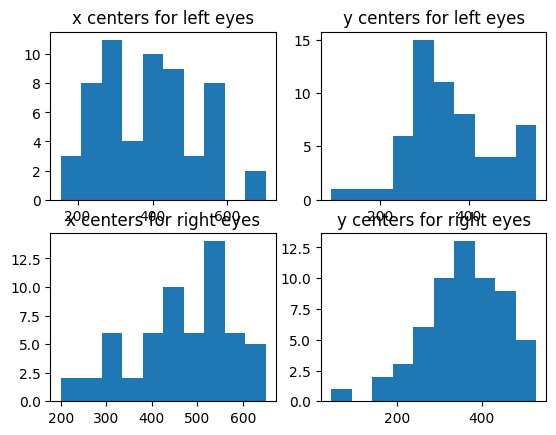

In [56]:
fig, axs = plt.subplots(2, 2)


axs[0, 0].hist(left_sheet.pos_centre_x)
axs[0, 0].set_title('x centers for left eyes')
axs[0, 1].hist(left_sheet.pos_centre_y)
axs[0, 1].set_title('y centers for left eyes')

axs[1, 0].hist(right_sheet.pos_centre_x)
axs[1, 0].set_title('x centers for right eyes')
axs[1, 1].hist(right_sheet.pos_centre_y)
axs[1, 1].set_title('y centers for right eyes')
fig.show()

In [6]:
len_r = right_sheet.pos_centre_x.size
len_l = left_sheet.pos_centre_x.size


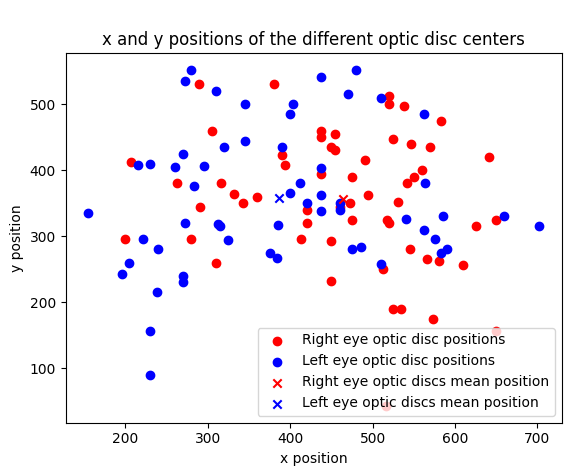

In [23]:
fig, ax = plt.subplots()
ax.scatter(right_sheet.pos_centre_x[:-1], right_sheet.pos_centre_y[:-1], c="RED", label="Right eye optic disc positions")
ax.scatter(left_sheet.pos_centre_x[:-1], left_sheet.pos_centre_y[:-1], c="BLUE", label="Left eye optic disc positions" )

# plot the mean 
ax.scatter(right_sheet.pos_centre_x[len_r-1], right_sheet.pos_centre_y[len_r-1], c="RED", marker="x", label="Right eye optic discs mean position")
ax.scatter(left_sheet.pos_centre_x[len_l-1], left_sheet.pos_centre_y[len_l-1], c="BLUE", marker="x", label="Left eye optic discs mean position")
plt.title("\nx and y positions of the different optic disc centers")
plt.xlabel("x position")
plt.ylabel("y position")
ax.legend(loc='lower right')
plt.show()

Conclusion of all those stats on x positions :
Not that conclusive, the positions are very widespread, it's just the mean that is SLIGHTLY more to the left or the right depending on the kind of eye we're working with. 

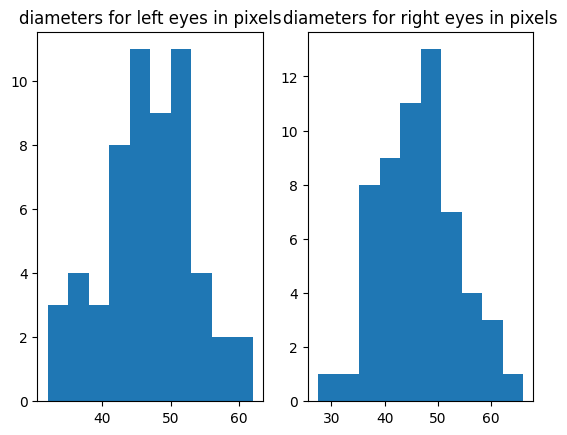

In [48]:
# Different ways to represent stats

fig, axs = plt.subplots(1, 2)
mean_diameter_left = (left_sheet.Diam_x_Rouge[:len_l-1] + left_sheet.Diam_y_Rouge[:len_l-1])/2

mean_diameter_right = (right_sheet.Diam_x_Rouge[:len_r-1] + right_sheet.Diam_y_Rouge[:len_r-1])/2

axs[0].hist(mean_diameter_left)
axs[0].set_title('diameters for left eyes in pixels')
axs[1].hist(mean_diameter_right)
axs[1].set_title('diameters for right eyes in pixels')
plt.show()